In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.interpolate import RegularGridInterpolator
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import pandas as pd
import seaborn as sns
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning
from utils.bayesian_opt_utils import generate_oil_field_gauss, drill_for_oil_interpolated, expected_improvement, \
    plot_bo_step_2d

# Ignore the scikit-learn convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [16]:
np.random.seed(42)

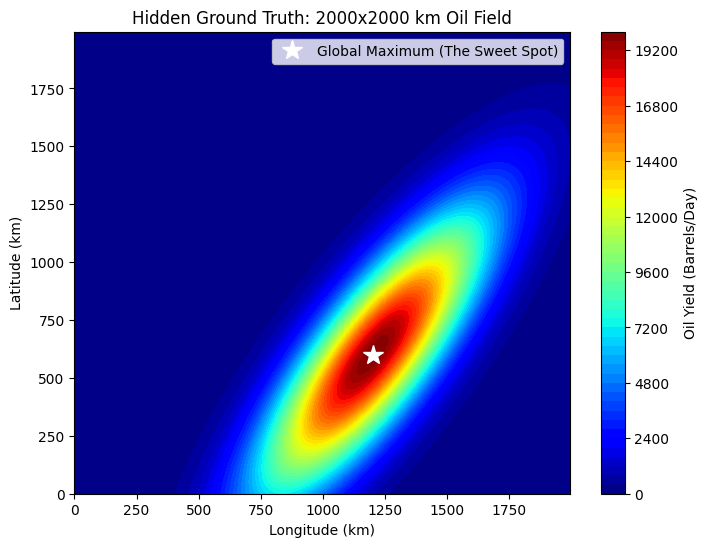

In [17]:


# --- Execution & Visualization ---
X, Y, oil_yield = generate_oil_field_gauss(grid_size=2000, resolution=5, max_yield=20000, angle=-35.0)

plt.figure(figsize=(8, 6))
# We use contourf to create a filled contour plot (like a topographic map)
contour = plt.contourf(X, Y, oil_yield, levels=50, cmap='jet')
plt.colorbar(contour, label='Oil Yield (Barrels/Day)')
plt.plot(1200, 600, 'w*', markersize=15, label='Global Maximum (The Sweet Spot)')
plt.title('Hidden Ground Truth: 2000x2000 km Oil Field')
plt.xlabel('Longitude (km)')
plt.ylabel('Latitude (km)')
plt.legend()
plt.show()

In [18]:
# --- How you would use it with your existing data ---
# Let's say we want to drill 5 initial random wells

initial_drills = np.random.uniform(0, 2000, size=(5, 2))

# We pass in the X, Y, and oil_yield arrays you already generated
initial_yields = drill_for_oil_interpolated(initial_drills, X, Y, oil_yield)

print("Drill Coordinates (X, Y):")
print(np.round(initial_drills, 1))
print("\nInterpolated Yields (Barrels/Day):")
print(np.round(initial_yields, 1))

Drill Coordinates (X, Y):
[[ 749.1 1901.4]
 [1464.  1197.3]
 [ 312.   312. ]
 [ 116.2 1732.4]
 [1202.2 1416.1]]

Interpolated Yields (Barrels/Day):
[   0.  6225.4    0.     0.    89.3]


In [19]:
# 3. Define the Gaussian Process Kernel
# We use a Radial Basis Function (RBF) which is the same as the Squared Exponential.
# We give it an initial length scale of 100 km (how far we think geological features stretch).
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[100, 100], length_scale_bounds=(10, 10000))

# We set normalize_y=True because our oil yields are huge (up to 10,000), 
# and GPs work best when the target variable is scaled around 0.
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)

# 4. Fit the GP (Train the Surrogate)
gp.fit(initial_drills, initial_yields)

print(f"Optimized Kernel parameters after fitting: {gp.kernel_}")

Optimized Kernel parameters after fitting: 0.999**2 * RBF(length_scale=[93.2, 1e+04])


In [20]:
# Assuming we have our trained 'gp' and our 'initial_yields'
best_current_yield = np.max(initial_yields)

# Create a list of all possible coordinates to check 
# (using the 20km resolution grid from earlier)
x_pred = np.arange(0, 2000, 20)
y_pred = np.arange(0, 2000, 20)
X_pred_grid, Y_pred_grid = np.meshgrid(x_pred, y_pred)
all_coordinates = np.vstack((X_pred_grid.flatten(), Y_pred_grid.flatten())).T

# Calculate EI for the entire map
ei_values = expected_improvement(all_coordinates, gp, best_current_yield)

# Find the index of the highest EI score
best_index = np.argmax(ei_values)

# Get the exact coordinate for Drill #6
next_drill_site = all_coordinates[best_index]

print(f"The smartest place to drill next is at (X, Y): {next_drill_site}")
print(f"Expected Improvement score: {np.round(ei_values[best_index], 2)}")

The smartest place to drill next is at (X, Y): [1520 1200]
Expected Improvement score: 234.31


Starting Bayesian Optimization Loop...

Step   | Coordinate (X, Y)    | Expected Improvement   | Actual Yield (bbl/day)
---------------------------------------------------------------------------


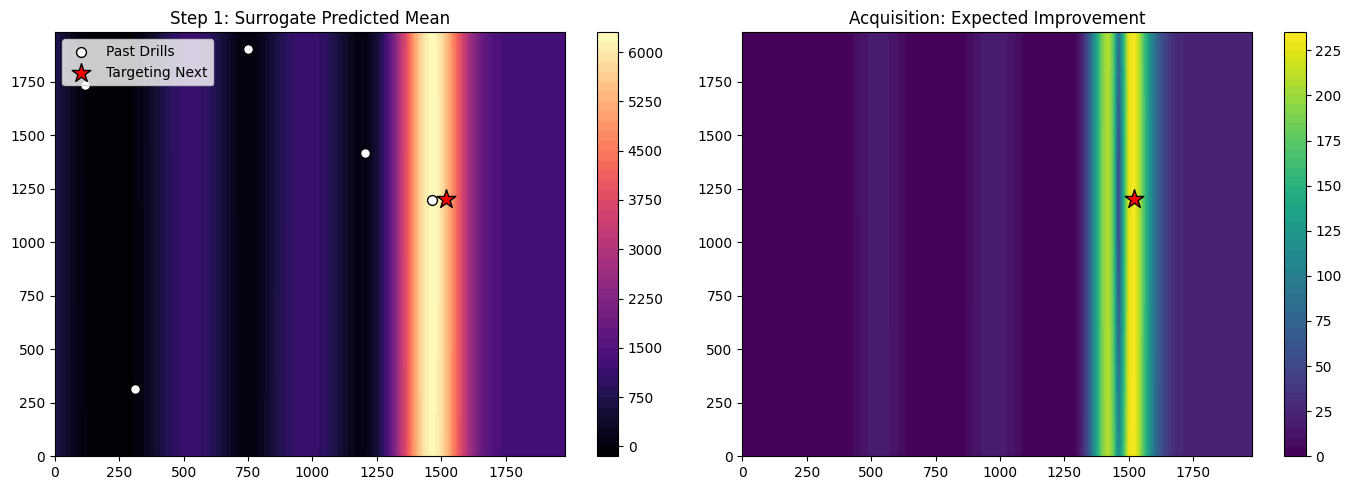

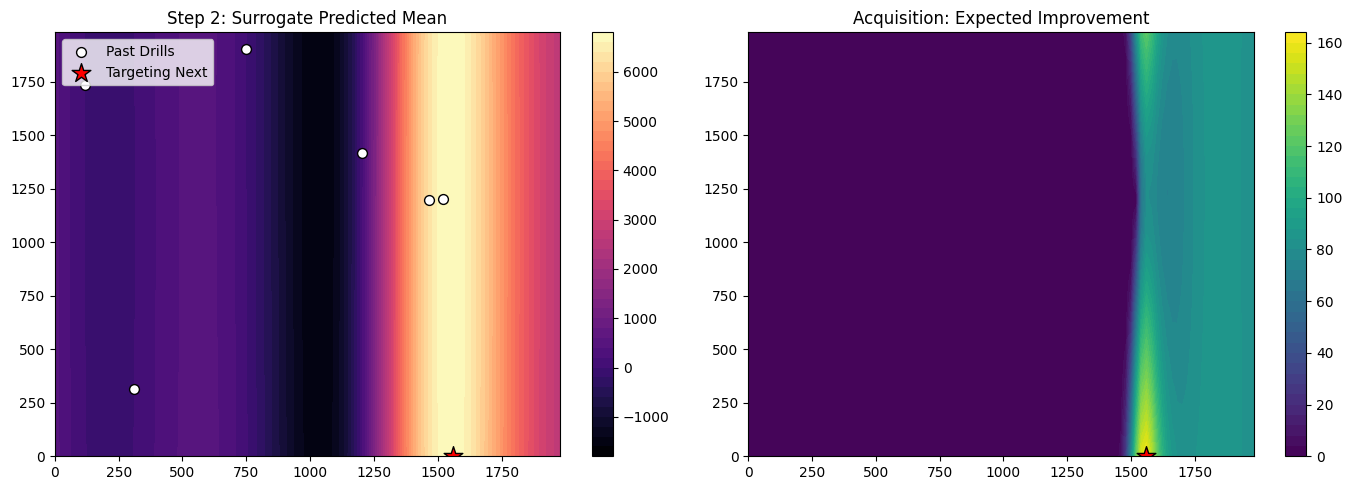

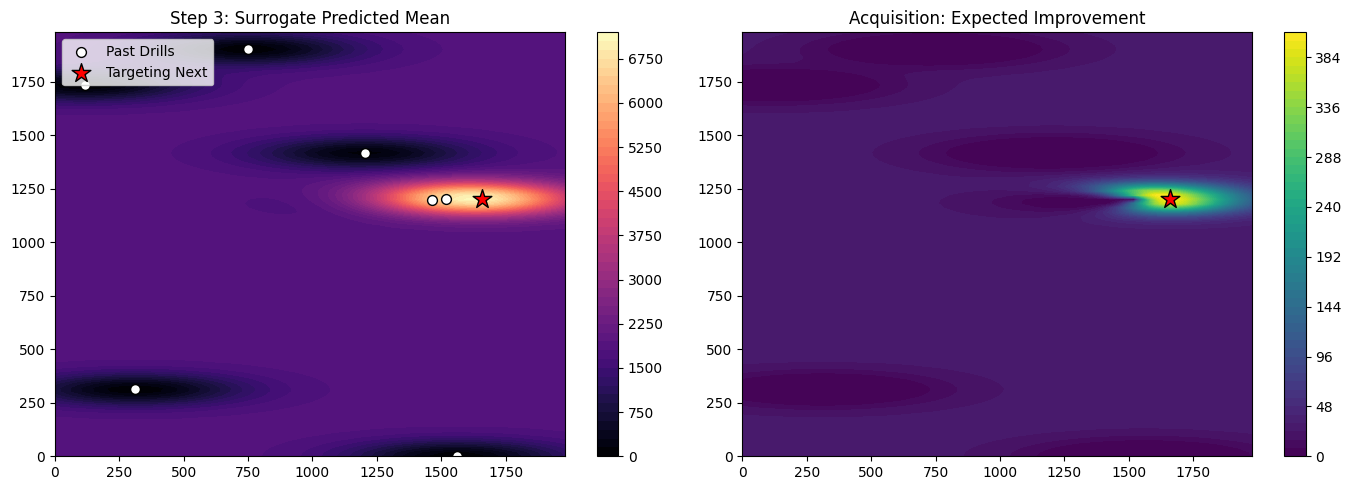

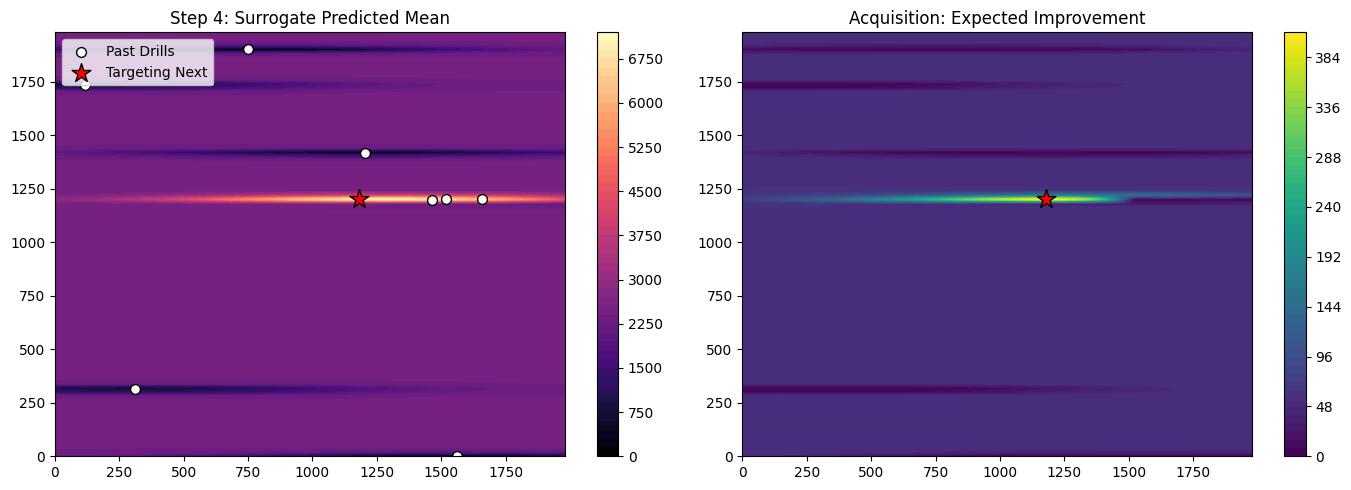

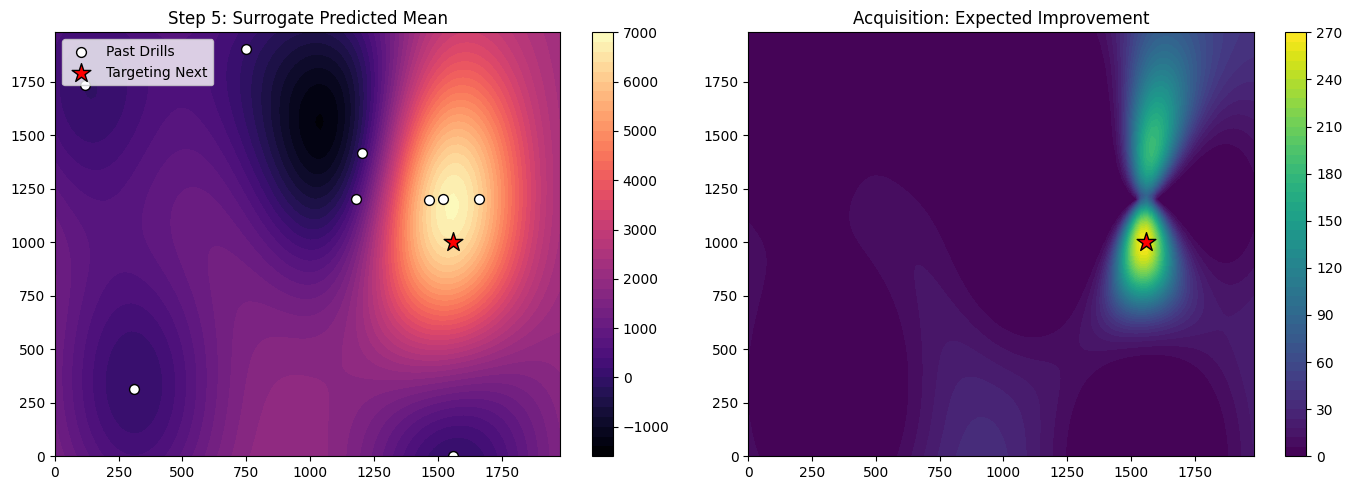

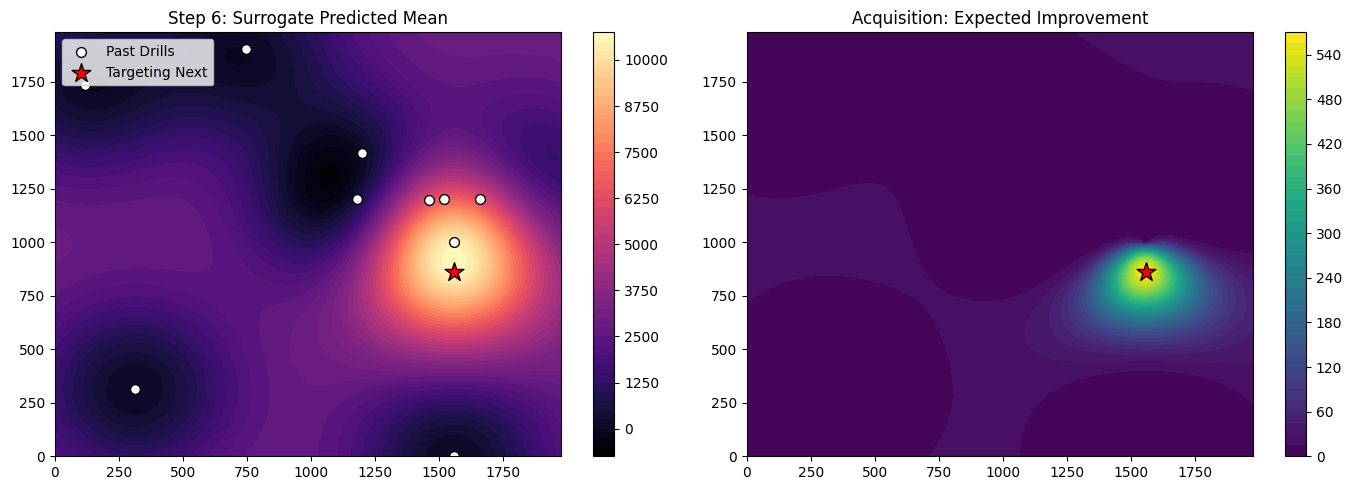

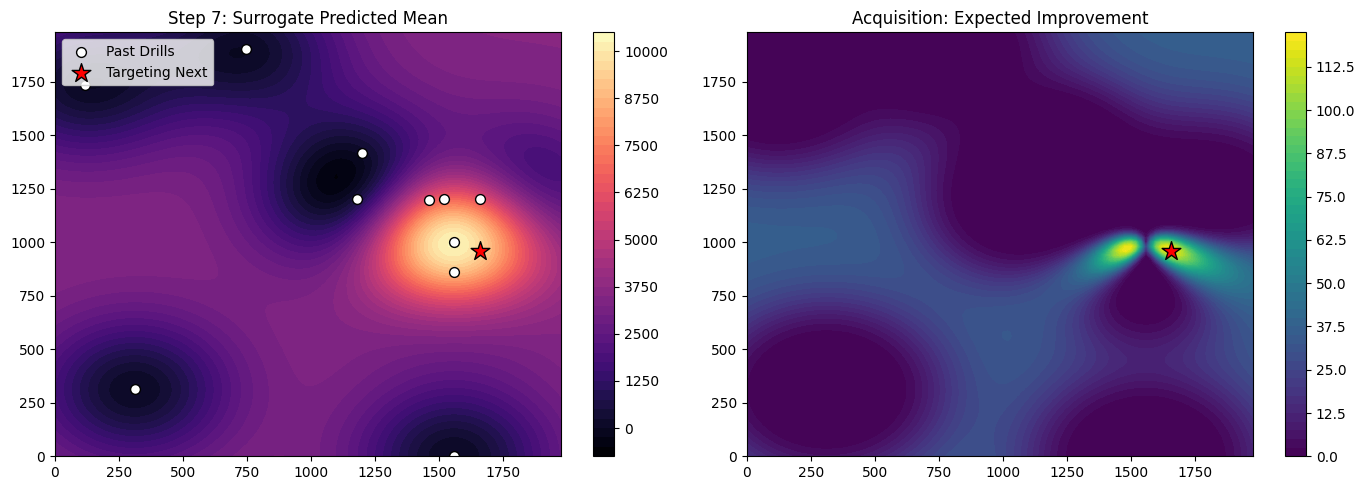

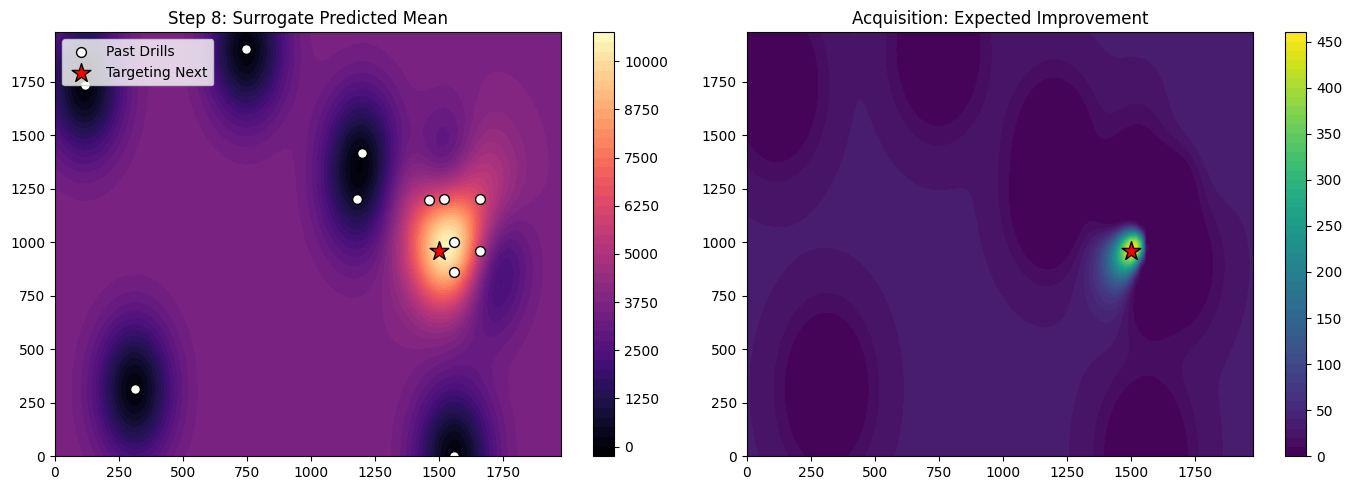

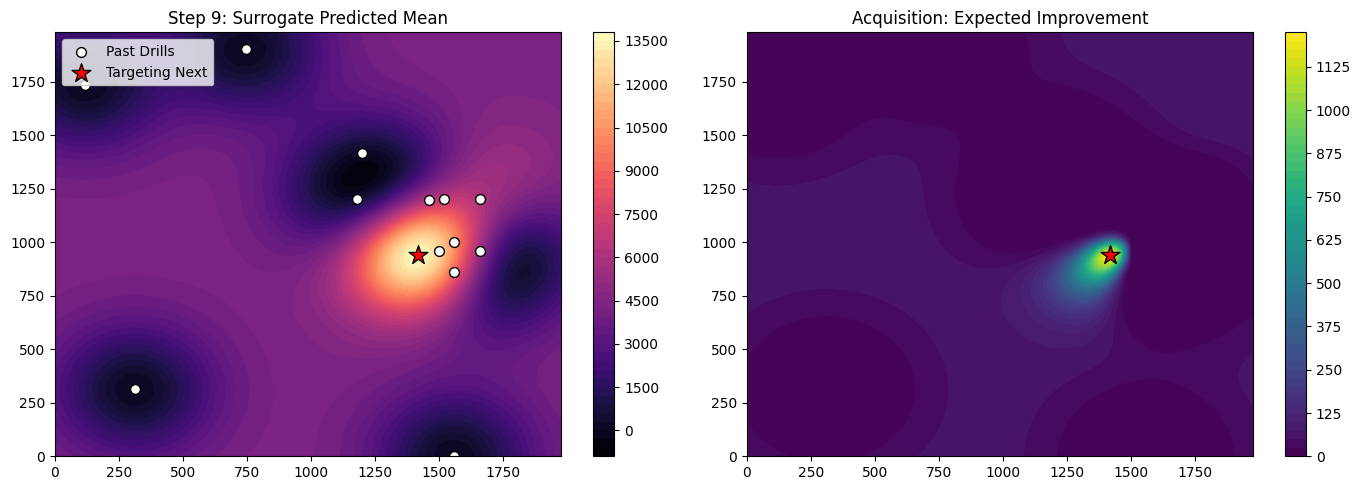

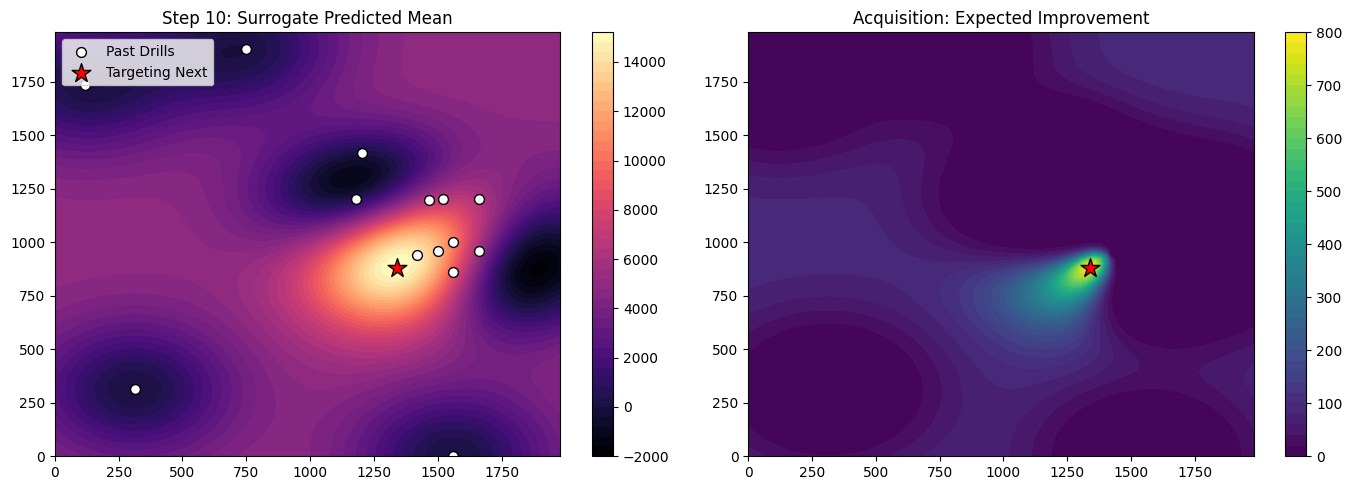

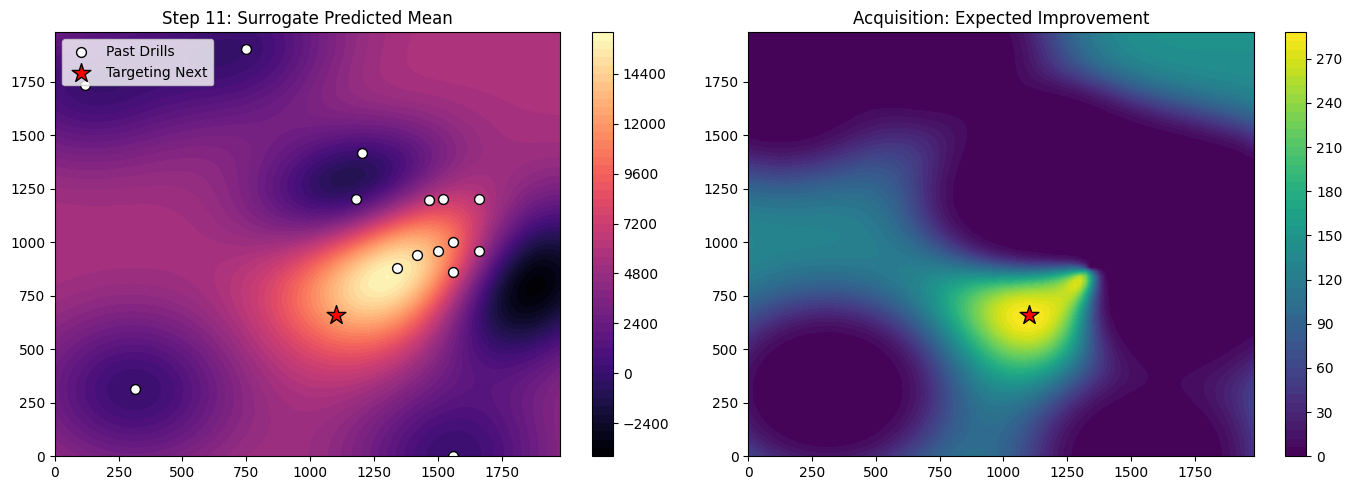

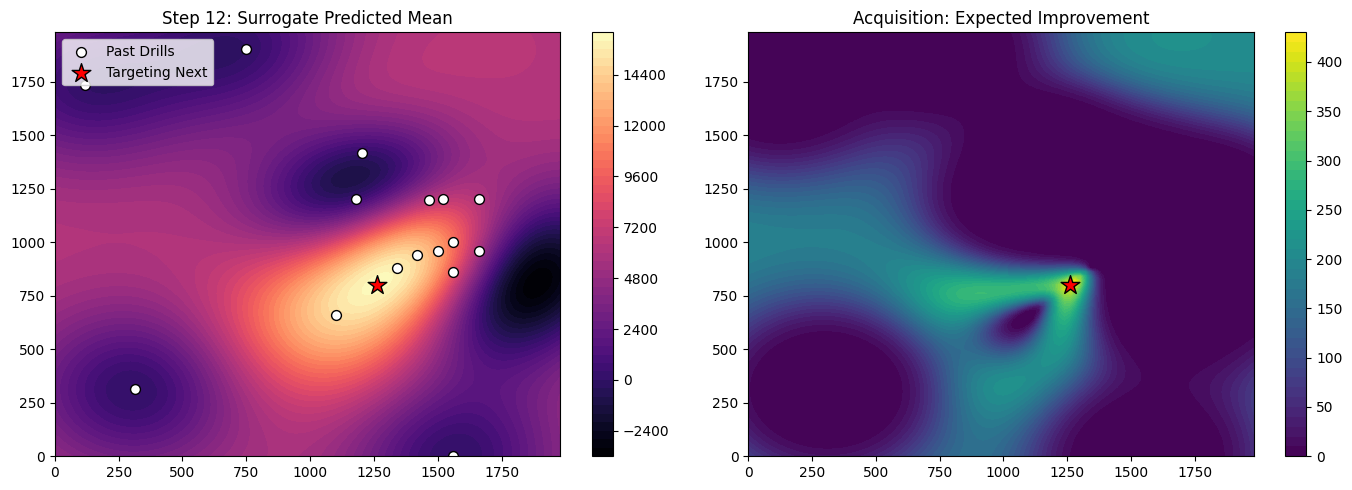

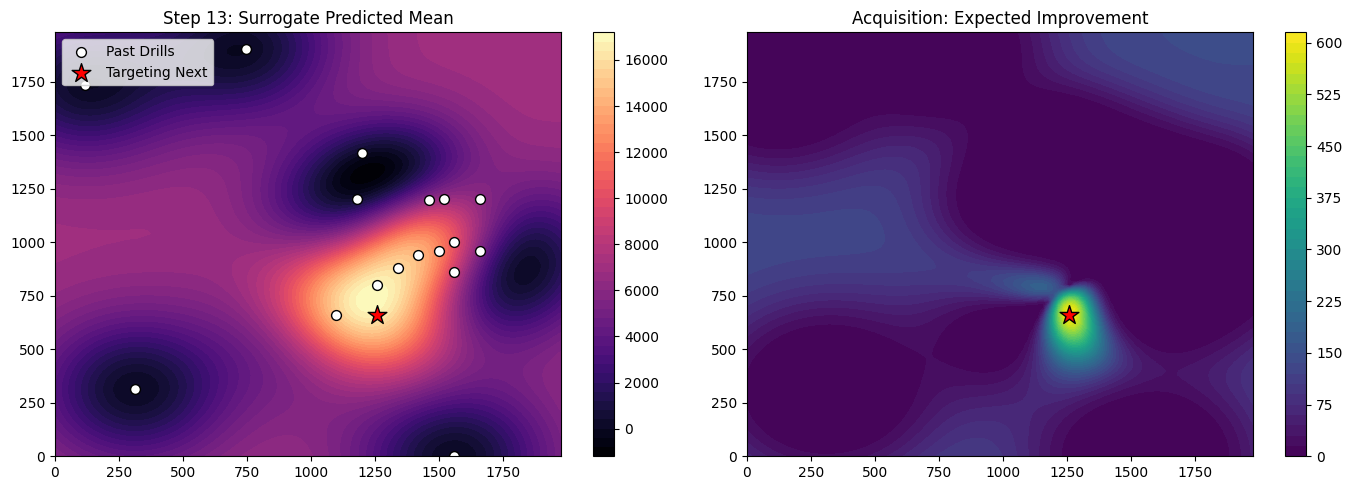

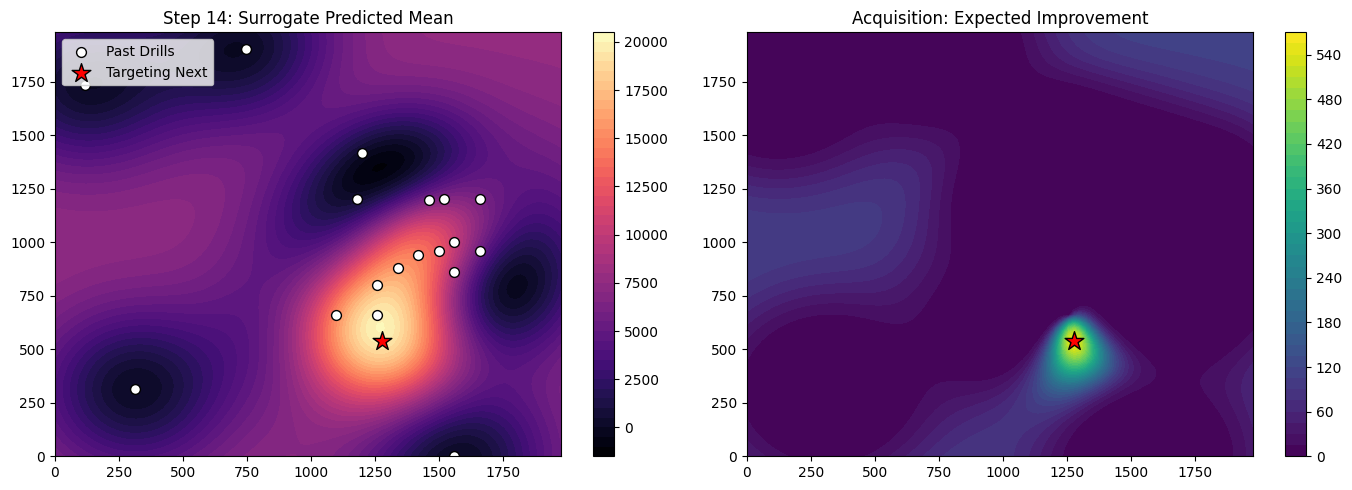

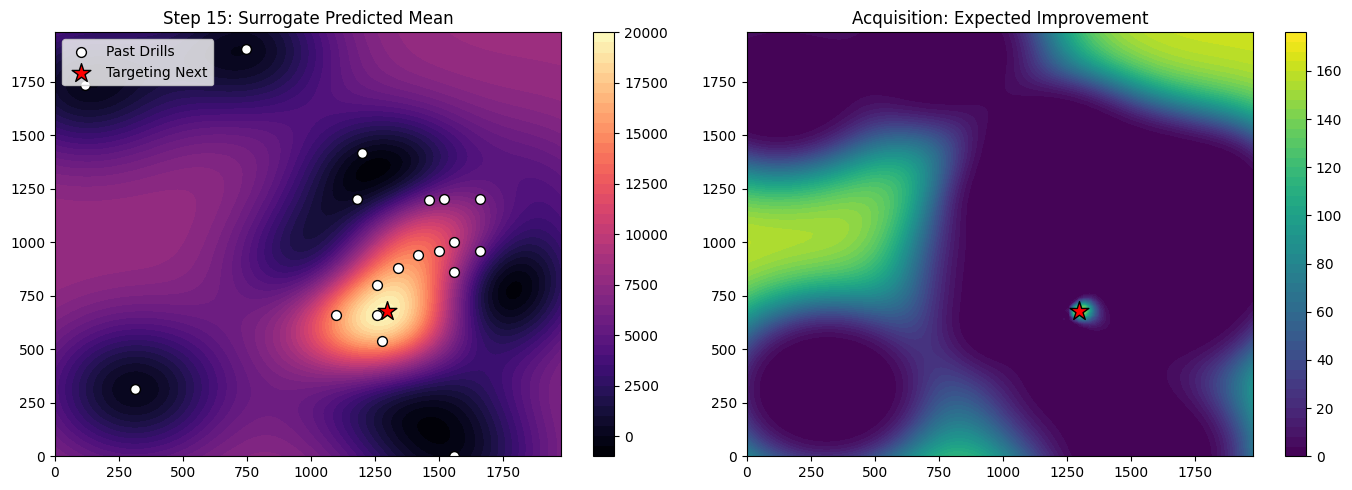


Bayesian Optimization Loop History:
Step   | Coordinate (X, Y)    | Expected Improvement   | Actual Yield (bbl/day)
---------------------------------------------------------------------------
1      | (1520, 1200)         | 234.31                 | 6732.03               
2      | (1560, 0)            | 161.31                 | 0.00                  
3      | (1660, 1200)         | 407.44                 | 6189.68               
4      | (1180, 1200)         | 407.00                 | 547.11                
5      | (1560, 1000)         | 268.14                 | 10283.45              
6      | (1560, 860)          | 561.41                 | 8835.43               
7      | (1660, 960)          | 121.06                 | 5536.30               
8      | (1500, 960)          | 455.91                 | 12423.94              
9      | (1420, 940)          | 1206.92                | 14411.52              
10     | (1340, 880)          | 784.70                 | 15765.29              
11     

In [21]:
# --- 1. Setup the Search Grid ---
# We create a 20km resolution grid of coordinates to evaluate EI on.
# (This represents every possible place we might decide to drill next)
x_search = np.arange(0, 2000, 20)
y_search = np.arange(0, 2000, 20)
X_search_grid, Y_search_grid = np.meshgrid(x_search, y_search)
search_coordinates = np.vstack((X_search_grid.flatten(), Y_search_grid.flatten())).T

# --- 2. Initialize tracking arrays ---
# We start with the 5 random drills we did earlier
current_drills = np.copy(initial_drills)
current_yields = np.copy(initial_yields)

print("Starting Bayesian Optimization Loop...\n")
print(f"{'Step':<6} | {'Coordinate (X, Y)':<20} | {'Expected Improvement':<22} | {'Actual Yield (bbl/day)':<22}")
print("-" * 75)

num_steps = 15

history_logs = []  # To store the history of each step for later analysis

# --- 3. The Optimization Loop ---
for step in range(1, num_steps + 1):
    # Step A: Train the Surrogate Model
    # We update the GP with all the data we have collected so far
    gp.fit(current_drills, current_yields)
    
    # Step B: Find our current best well
    best_current_yield = np.max(current_yields)
    
    # Step C: Calculate Expected Improvement for every point on the map
    # We pass xi=0.01 to ensure a tiny bit of exploration
    ei_values = expected_improvement(search_coordinates, gp, best_current_yield, xi=0.01)
    
    # Step D: Pick the Winner
    best_index = np.argmax(ei_values)
    next_drill_site = search_coordinates[best_index]
    max_ei = ei_values[best_index]
    
    # Step E: "Drill" at the chosen coordinate (The Expensive Real-World Step)
    # We format it as a 2D array (1 row, 2 columns) for the interpolator
    actual_yield = drill_for_oil_interpolated(next_drill_site.reshape(1, -1), X, Y, oil_yield)[0]

    plot_bo_step_2d(X_search_grid, Y_search_grid, gp, ei_values, current_drills, next_drill_site, step)
    
    # Step F: Print the results for this iteration
    coord_str = f"({next_drill_site[0]:.0f}, {next_drill_site[1]:.0f})"
    history_logs.append((step, coord_str, max_ei, actual_yield))
    
    # Step G: Add the new data to our historical records for the next loop
    current_drills = np.vstack((current_drills, next_drill_site))
    current_yields = np.append(current_yields, actual_yield)

print("\nBayesian Optimization Loop History:")
print(f"{'Step':<6} | {'Coordinate (X, Y)':<20} | {'Expected Improvement':<22} | {'Actual Yield (bbl/day)':<22}")
print("-" * 75)

# Loop through our saved logs and print them out in order
for log in history_logs:
    step, coord_str, max_ei, actual_yield = log
    print(f"{step:<6} | {coord_str:<20} | {max_ei:<22.2f} | {actual_yield:<22.2f}")

print("-" * 75)
best_overall_index = np.argmax(current_yields)
print(f"\nOptimization Complete!")
print(f"Best Well Found At: {current_drills[best_overall_index]}")
print(f"Maximum Yield: {current_yields[best_overall_index]:.2f} barrels/day")

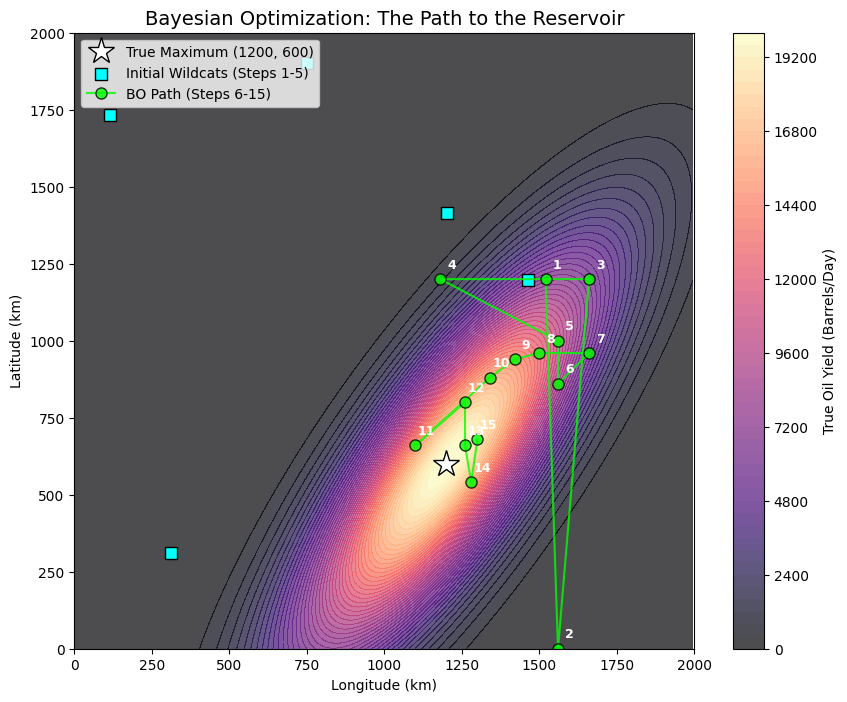

In [22]:
plt.figure(figsize=(10, 8))

# 1. Plot the underlying ground truth (The hidden map we created earlier)
# We set alpha=0.7 to make the background slightly transparent
contour = plt.contourf(X, Y, oil_yield, levels=50, cmap='magma', alpha=0.7)
plt.colorbar(contour, label='True Oil Yield (Barrels/Day)')

# 2. Mark the absolute "Perfect" drill site so we know what we were aiming for
plt.plot(1200, 600, 'w*', markersize=20, markeredgecolor='black', label='True Maximum (1200, 600)')

# 3. Plot the 5 Initial Random "Wildcat" Drills
plt.scatter(current_drills[:5, 0], current_drills[:5, 1], 
            c='cyan', marker='s', s=80, edgecolors='black', 
            label='Initial Wildcats (Steps 1-5)')

# 4. Plot the 20 Bayesian Optimization Iterations
# We use a line to trace the exact order the algorithm visited them
plt.plot(current_drills[5:, 0], current_drills[5:, 1], 
         c='lime', marker='o', markersize=8, markeredgecolor='black', 
         linestyle='-', linewidth=1.5, alpha=0.8, label='BO Path (Steps 6-15)')

# 5. Add text numbers next to the BO steps so we can follow the timeline
for i in range(5, len(current_drills)):
    step_number = i - 4 # So the first BO step is labeled '1'
    plt.annotate(str(step_number), 
                 (current_drills[i, 0], current_drills[i, 1]), 
                 textcoords="offset points", xytext=(8, 8), 
                 ha='center', fontsize=9, color='white', weight='bold')

# Formatting the plot
plt.title('Bayesian Optimization: The Path to the Reservoir', fontsize=14)
plt.xlabel('Longitude (km)')
plt.ylabel('Latitude (km)')
plt.xlim(0, 2000)
plt.ylim(0, 2000)
plt.legend(loc='upper left')

plt.show()